# 📊 Customer Lifetime Value (LTV) Prediction Project

This project is focusing on the regression problem. We are using a dataset from kaggle called Digital Wallet Transactions. This dataset has the transaction details of customers, along with their personal details and customer behaviors.

In the business use, by predicting future user value / purchase probability using historical behavior and the predictors, and identify the most important factors driving performance. User cases can be referred to focus on predicted low volume customers, companies may put more effort to drive their performance


Dataset link: https://www.kaggle.com/datasets/harunrai/digital-wallet-transactions/data

In this project, we are aiming at applying RandomForest, AdaBoost, XGBoost, Neural Network(MLP) on the dataset to perform model training, validation and testing. To find out the best model to perform future forecast. 


This project is using the following steps:


## 1. Data Splitting Strategy (Time-Aware & Leakage-Safe)

The dataset is split into **Training (60%)**, **Validation (20%)**, and **Testing (20%)** sets after sorting observations by `Active_Days`.

**Why not random splitting?**  
Customer Lifetime Value (LTV) is an accumulative variable that evolves over time.  
A random split would introduce **look-ahead bias**, where future customer behavior leaks into the training process.

By sorting on `Active_Days`, we create a **pseudo-temporal ordering**, ensuring:
- the training set contains earlier customer histories,
- the validation set represents more recent customers,
- the test set simulates unseen future data.

This design closely resembles a **backtesting setup** for non-time-series data and prevents temporal leakage.

---

## 2. Preprocessing Design (Consistency & Reproducibility)

All preprocessing steps are implemented using **scikit-learn Pipelines and ColumnTransformers**, ensuring:

- transformations are learned **only on training data within each CV fold**,
- no information leakage across train, validation, or test sets,
- full reproducibility and clean experiment tracking.

### Numeric Features
Numeric variables are processed using:
- **Median imputation** (robust to skewness and outliers),
- **Standard scaling** (zero mean, unit variance).

**Note:**  
Scaling is applied to:
- ensure stable optimization for scale-sensitive models (MLP),
- maintain consistent preprocessing across all evaluated models.

Tree-based models are invariant to monotonic transformations, so scaling does not affect their performance.

### Categorical Features
Categorical variables are handled using:
- most-frequent imputation,
- one-hot encoding with a dropped reference category to avoid perfect multicollinearity.

---

## 3. Why the Same Preprocessing Is Used for All Models

Although not all models require scaling, **the same preprocessing pipeline is applied to all models intentionally**.

This ensures:
- differences in performance are attributable to the models themselves,
- preprocessing choices do not confound model comparison,
- experimental results are fair and interpretable.

This design choice prioritizes **methodological consistency over model-specific optimization**.

---

## 4. Model Choices and Experimental Coverage

Four model families are evaluated to cover diverse learning paradigms:

- **Random Forest**  
  A strong non-linear baseline using bagging and feature randomness.

- **XGBoost**  
  A gradient boosting model optimized for structured/tabular data.

- **AdaBoost**  
  A boosting algorithm emphasizing difficult-to-predict observations.

- **Multilayer Perceptron (MLP)**  
  A neural network included to test whether higher-order non-linear representations improve performance.

This diversity strengthens conclusions and reduces reliance on any single modeling assumption.

---

## 5. Hyperparameter Tuning (Time-Aware Cross-Validation)

Hyperparameter tuning is conducted using **RandomizedSearchCV with TimeSeriesSplit**, applied **only to the training set**.

Key design choices:
- Time-aware CV preserves temporal ordering inside folds.
- Preprocessing is refit inside each fold via pipelines.
- Validation data is never used for fitting or tuning.

This setup avoids both **temporal leakage** and **preprocessing leakage**.

---

## 6. Model Selection vs Final Training Logic

Model selection is based **exclusively on validation performance**.

Workflow:
1. Train and tune models using training data.
2. Compare models using validation RMSE and R².
3. Select the best-performing model.
4. Refit the selected model on **Training + Validation** data.
5. Evaluate final performance **once** on the test set.

This separation ensures:
- unbiased model comparison,
- maximal data usage for final training,
- honest generalization assessment.

---

## 7. Evaluation Metrics and Interpretation

Models are evaluated using:
- **RMSE** — penalizes large prediction errors,
- **R²** — measures explained variance.

Given:
- Mean LTV ≈ **512,000**
- Test RMSE ≈ **325,000**

The achieved performance is reasonable due to:
- high variance in customer behavior,
- unobserved future factors affecting LTV,
- inherent noise in long-term value prediction.

An R² around **0.4** indicates meaningful explanatory power for this application.

---

## 8. Log-Target Experiment (Neural Network)

Due to heavy right skew in LTV, a log-transformed target was tested for the MLP using `TransformedTargetRegressor`.

**Outcome:**
- Log transformation did not improve performance.
- Inverse transformation amplified prediction errors.
- Tree-based models handled skewness more effectively.

This experiment supports the final preference for ensemble tree methods.

---

## 9. Final Model Selection

**XGBoost** consistently achieved:
- the lowest validation RMSE,
- stable test performance,
- minimal validation–test performance gap.

This indicates:
- strong generalization,
- limited overfitting,
- robustness of the modeling pipeline.

XGBoost is therefore selected as the final model.

---

## 10. Practical and Business Implications

The model can be used to:
- identify high-value customers for retention,
- target low-value customers for activation,
- prioritize marketing spend based on predicted lifetime value.

In practice, **relative ranking of customers** is often more actionable than exact point estimates.

---

## 11. Summary

This project combining:

- time-aware data splitting,
- consistent preprocessing,
- multi-model comparison,
- robust hyperparameter tuning,
- and unbiased final evaluation.



## Model Comparison Results

The table below summarizes the performance of all evaluated models on both the **validation** and **test** datasets.  
Validation performance is used for **model selection**, while test performance is reported only once to assess final generalization.

| Model           | Val MAE | Val RMSE | Val R² | Test MAE | Test RMSE | Test R² |
|-----------------|---------|----------|--------|----------|-----------|---------|
| **XGBoost**     | 249,269 | 323,846  | 0.456  | 242,953  | 324,799   | 0.410   |
| Random Forest   | 256,901 | 331,307  | 0.430  | 246,082  | 325,080   | 0.409   |
| AdaBoost        | 255,966 | 331,763  | 0.428  | 243,703  | 325,303   | 0.409   |
| MLP             | 255,278 | 332,831  | 0.425  | 242,520  | 324,374   | 0.412   |
| MLP (Log LTV)   | 528,026 | 686,537  | -1.448 | 483,887  | 642,701   | -1.309  |

### Interpretation

Several important patterns emerge from the results:

- **XGBoost achieves the lowest validation RMSE** and the highest validation R², making it the best-performing model during model selection.
- The **validation and test metrics are very close** for XGBoost, Random Forest, AdaBoost, and the standard MLP, indicating stable generalization and no severe overfitting.
- The **log-transformed MLP performs significantly worse**, with negative R² values on both validation and test sets. This suggests that, for this dataset, log-transforming the target amplifies errors when predictions are transformed back to the original scale.
- Although the MLP slightly outperforms XGBoost on test R², its validation performance is weaker, so it is not selected.

Given that model selection should rely on **validation performance only**, **XGBoost is chosen as the final model**.

---

## Final Model Training and Testing

After selecting XGBoost based on validation performance, the model is **refit using the combined training and validation data** to make full use of all available historical information.

The refitted model is then evaluated once on the held-out test set:

- **Test RMSE ≈ 324,800**
- **Test R² ≈ 0.41**

The mean LTV in the dataset is approximately **512,000**, so the final RMSE corresponds to roughly **60–65% of the average LTV**, which is reasonable given the noisy and long-term nature of customer lifetime value.

This confirms that the selected model generalizes well and that the validation-based selection process was appropriate.


In [256]:
# =========================
# Core Python
# =========================
import os
import time
import random
import warnings

warnings.filterwarnings("ignore")

# =========================
# Numerical & Data Handling
# =========================
import numpy as np
import pandas as pd

# =========================
# Visualization
# =========================
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# Progress / Utilities
# =========================
from tqdm import tqdm

# =========================
# Stats / Econometrics
# =========================
import statsmodels.api as sm

# =========================
# Scikit-learn – Core
# =========================
from sklearn.base import clone
from sklearn.dummy import DummyRegressor

# =========================
# Scikit-learn – Model Selection
# =========================
from sklearn.model_selection import (
    train_test_split,
    KFold,
    TimeSeriesSplit,
    RandomizedSearchCV
)

# =========================
# Scikit-learn – Preprocessing & Pipelines
# =========================
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# =========================
# Scikit-learn – Metrics (Regression)
# =========================
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# =========================
# Scikit-learn – Linear Models
# =========================
from sklearn.linear_model import LinearRegression, Ridge

# =========================
# Scikit-learn – Tree / Ensemble Models
# =========================
from sklearn.ensemble import (
    RandomForestRegressor,
    HistGradientBoostingRegressor
)

# =========================
# Scikit-learn – Neural Networks
# =========================
from sklearn.neural_network import MLPRegressor

# =========================
# Model Inspection
# =========================
from sklearn.inspection import permutation_importance


In [ ]:
# read dataset in csv
df = pd.read_csv("regression.csv")

In [215]:
df.head()

,Customer_ID,Age,Location,Income_Level,Total_Transactions,Avg_Transaction_Value,Max_Transaction_Value,Min_Transaction_Value,Total_Spent,Active_Days,Last_Transaction_Days_Ago,Loyalty_Points_Earned,Referral_Count,Cashback_Received,App_Usage_Frequency,Preferred_Payment_Method,Support_Tickets_Raised,Issue_Resolution_Time,Customer_Satisfaction_Score,LTV
0,cust_0000,54,Urban,Low,192,16736.384023,60216.834510,6525.814861,3.213386e+06,140,209,2114,25,2224.012140,Monthly,Debit Card,3,61.568590,1,3.279546e+05
1,cust_0001,67,Suburban,High,979,14536.734683,48350.100272,2186.742245,1.423146e+07,229,240,2960,20,4026.823518,Monthly,UPI,17,60.392889,8,1.437053e+06
2,cust_0002,44,Urban,High,329,7061.372800,32521.157187,2743.406808,2.323192e+06,73,21,3170,0,1441.011395,Monthly,Debit Card,11,45.305579,4,2.419387e+05
3,cust_0003,30,Rural,High,71,16426.876453,17827.896720,4360.784994,1.166308e+06,299,285,4756,35,4365.855580,Weekly,Wallet Balance,6,22.030191,1,1.284599e+05
4,cust_0004,58,Urban,Middle,878,10800.092660,17497.634534,4532.872520,9.482481e+06,236,329,1992,18,4161.523827,Daily,UPI,18,20.634723,5,9.569514e+05


In [216]:
# drop Customer_ID since it doesn't contain important information
df = df.drop(columns=['Customer_ID'])
print(df.shape)


(7000, 19)


In [217]:
df.head()

,Age,Location,Income_Level,Total_Transactions,Avg_Transaction_Value,Max_Transaction_Value,Min_Transaction_Value,Total_Spent,Active_Days,Last_Transaction_Days_Ago,Loyalty_Points_Earned,Referral_Count,Cashback_Received,App_Usage_Frequency,Preferred_Payment_Method,Support_Tickets_Raised,Issue_Resolution_Time,Customer_Satisfaction_Score,LTV
0,54,Urban,Low,192,16736.384023,60216.834510,6525.814861,3.213386e+06,140,209,2114,25,2224.012140,Monthly,Debit Card,3,61.568590,1,3.279546e+05
1,67,Suburban,High,979,14536.734683,48350.100272,2186.742245,1.423146e+07,229,240,2960,20,4026.823518,Monthly,UPI,17,60.392889,8,1.437053e+06
2,44,Urban,High,329,7061.372800,32521.157187,2743.406808,2.323192e+06,73,21,3170,0,1441.011395,Monthly,Debit Card,11,45.305579,4,2.419387e+05
3,30,Rural,High,71,16426.876453,17827.896720,4360.784994,1.166308e+06,299,285,4756,35,4365.855580,Weekly,Wallet Balance,6,22.030191,1,1.284599e+05
4,58,Urban,Middle,878,10800.092660,17497.634534,4532.872520,9.482481e+06,236,329,1992,18,4161.523827,Daily,UPI,18,20.634723,5,9.569514e+05


In [218]:
# Dataset basic description
df.describe()

,Age,Total_Transactions,Avg_Transaction_Value,Max_Transaction_Value,Min_Transaction_Value,Total_Spent,Active_Days,Last_Transaction_Days_Ago,Loyalty_Points_Earned,Referral_Count,Cashback_Received,Support_Tickets_Raised,Issue_Resolution_Time,Customer_Satisfaction_Score,LTV
count,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7.000000e+03,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7.000000e+03
mean,42.633714,501.221429,9946.831482,30159.596784,2981.549953,5.002022e+06,181.934857,183.847714,2501.545429,24.837000,2496.525032,10.017571,36.528007,5.479000,5.119197e+05
std,15.516036,286.277311,5780.880831,21996.108793,2197.342161,4.390495e+06,105.102598,105.063709,1446.680026,14.560352,1440.651412,6.037067,20.389399,2.860197,4.390551e+05
min,16.000000,1.000000,10.185827,31.857484,4.617966,1.498144e+03,1.000000,1.000000,0.000000,0.000000,0.234349,0.000000,1.019853,1.000000,3.770495e+03
25%,29.000000,252.000000,4907.466790,12224.329366,1233.066226,1.363991e+06,90.000000,93.000000,1254.750000,12.000000,1269.423703,5.000000,19.127302,3.000000,1.482058e+05
50%,43.000000,506.000000,9841.172643,25469.392130,2473.181073,3.756105e+06,182.000000,184.000000,2466.000000,25.000000,2478.943350,10.000000,36.257396,5.000000,3.878180e+05
75%,56.000000,744.000000,14955.048801,44515.414177,4378.759195,7.645508e+06,273.000000,275.000000,3792.250000,37.000000,3749.375251,15.000000,54.068594,8.000000,7.748578e+05
max,69.000000,1000.000000,19996.445086,98809.241533,9917.028823,1.946773e+07,365.000000,365.000000,5000.000000,50.000000,4999.698480,20.000000,71.978946,10.000000,1.956988e+06


In [219]:
# Check the unique values of nominal variables to see the possibility of one-hot encoding
for col in ['Location', 'App_Usage_Frequency', 'Preferred_Payment_Method', 'Income_Level']:
    print(f"\n{col}:")
    print(df[col].unique())


Location:
['Urban' 'Suburban' 'Rural']

App_Usage_Frequency:
['Monthly' 'Weekly' 'Daily']

Preferred_Payment_Method:
['Debit Card' 'UPI' 'Wallet Balance' 'Credit Card']

Income_Level:
['Low' 'High' 'Middle']


In [220]:
# Check missing values
df.isna().sum()

Age                            0
Location                       0
Income_Level                   0
Total_Transactions             0
Avg_Transaction_Value          0
Max_Transaction_Value          0
Min_Transaction_Value          0
Total_Spent                    0
Active_Days                    0
Last_Transaction_Days_Ago      0
Loyalty_Points_Earned          0
Referral_Count                 0
Cashback_Received              0
App_Usage_Frequency            0
Preferred_Payment_Method       0
Support_Tickets_Raised         0
Issue_Resolution_Time          0
Customer_Satisfaction_Score    0
LTV                            0
dtype: int64

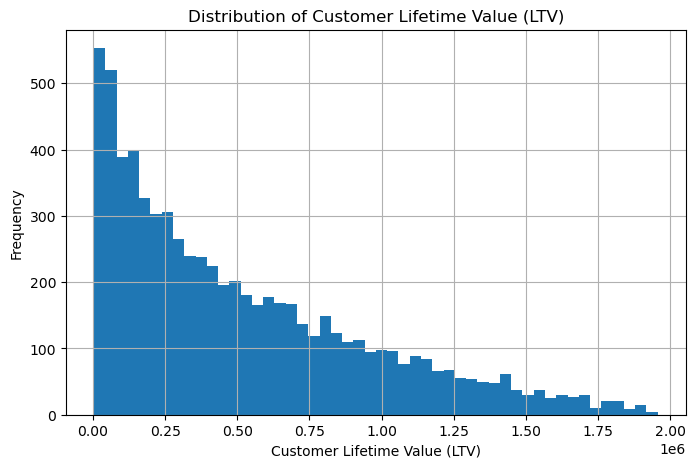

In [221]:
# Check the skewness of target variable
plt.figure(figsize=(8, 5))
plt.hist(df["LTV"], bins=50)
plt.xlabel("Customer Lifetime Value (LTV)")
plt.ylabel("Frequency")
plt.title("Distribution of Customer Lifetime Value (LTV)")
plt.grid(True)
plt.show()


The distribution of customer lifetime value is highly right-skewed, with most customers exhibiting low LTV and a small number of extreme high-value customers. This heavy-tailed structure introduces substantial noise and limits the achievable predictive performance. 

Since the to be used methods can handle skewed data well, we will use not transform LTV, however, for MLP, it doesn't handle skewed data well, we will perform log transformation to compare the performance.

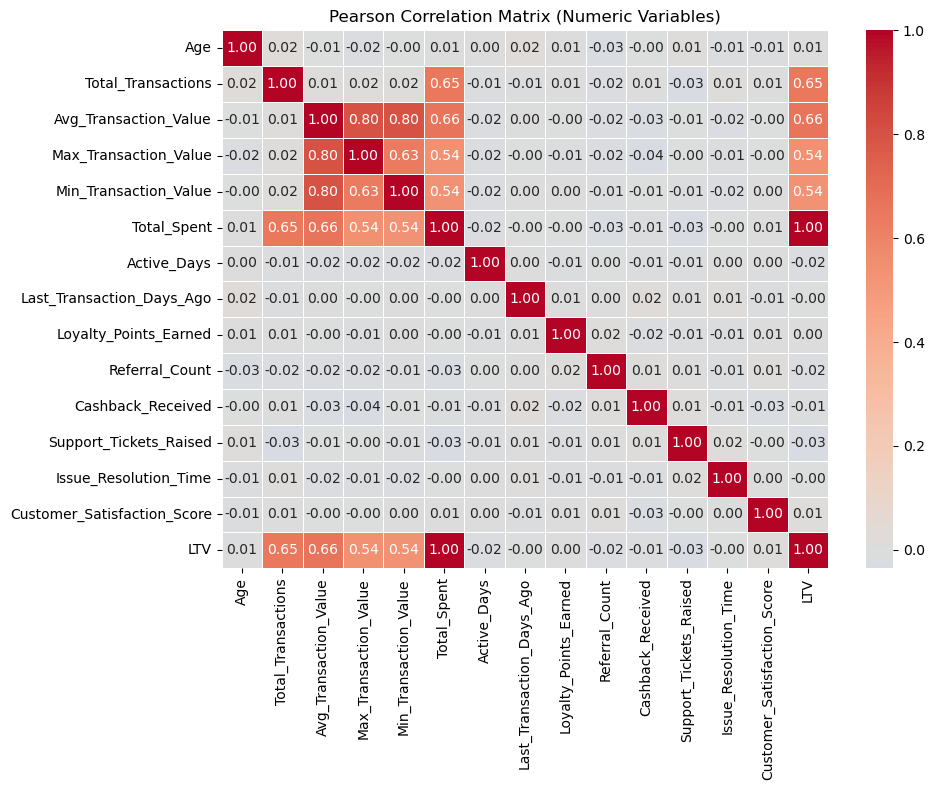

In [ ]:
num_df = df.select_dtypes(include=["int64", "float64"])

# Pearson correlation
pearson_corr = num_df.corr(method="pearson")


plt.figure(figsize=(10, 8))
sns.heatmap(
    pearson_corr,
    cmap="coolwarm",
    center=0,
    annot=True,        # show correlation values
    fmt=".2f",         # 2 decimals
    linewidths=0.5
)
plt.title("Pearson Correlation Matrix (Numeric Variables)")
plt.tight_layout()
plt.show()

Based on the correlation heatmap, we can clearly see that LTV and Total_Spent are having perfect correlation. And it is commonly used to measure the customer's LTV by using their Total_Spent in the finance industries, hence we will drop Total_Spent. 

For variables having over 0.7 correlation values, we will drop them as well. 

Even though Avg_Transaction_Value and LTV correlation value is only 0.66. It was observed that Avg_Transaction_Value is the result of Total_Spent divided by Total_Transaction. This would cause data leakage/redundant, hence we would remove Avg_Transaction_Value and keep the Total_Transactions.

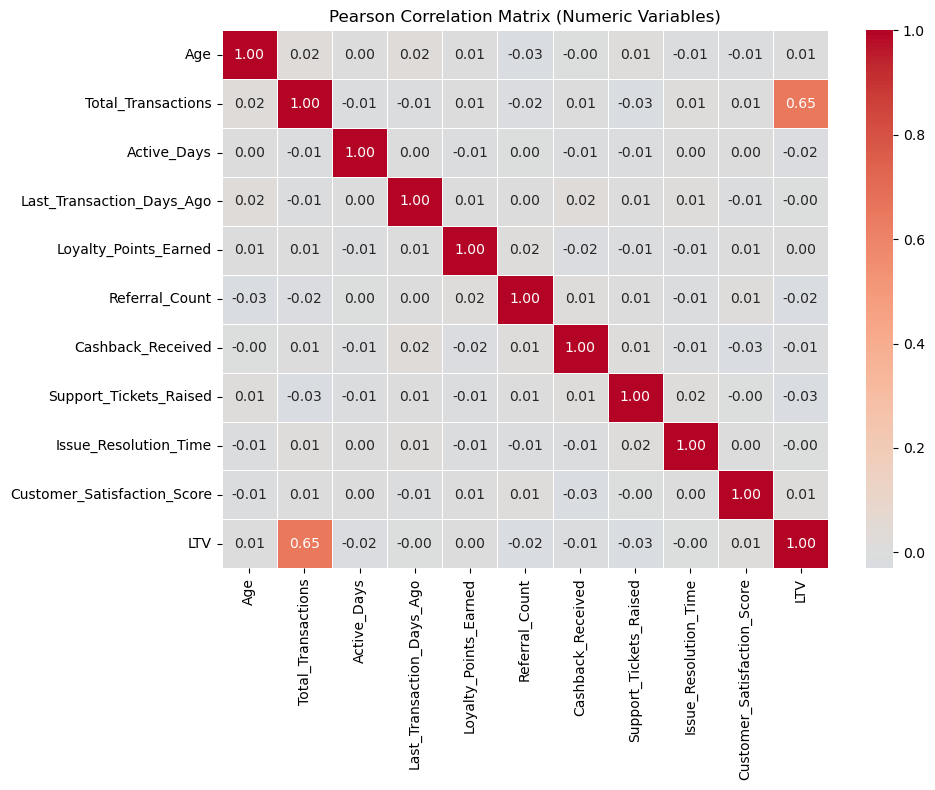

In [ ]:
# drop the variables mentioned
df = df.drop(columns= ['Max_Transaction_Value','Min_Transaction_Value', 'Avg_Transaction_Value', 'Total_Spent'])
num_df = df.select_dtypes(include=["int64", "float64"])

# Pearson correlation
pearson_corr = num_df.corr(method="pearson")


plt.figure(figsize=(10, 8))
sns.heatmap(
    pearson_corr,
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".2f",
    linewidths=0.5
)
plt.title("Pearson Correlation Matrix (Numeric Variables)")
plt.tight_layout()
plt.show()

In [224]:
# correlation for nominal variables using Cramér's V

def cramers_v(x, y):
    contingency = pd.crosstab(x, y)
    chi2 = chi2_contingency(contingency)[0]
    n = contingency.sum().sum()
    r, k = contingency.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))

cat_cols = [
    "Location",
    "App_Usage_Frequency",
    "Preferred_Payment_Method",
    "Income_Level"
]

# Initialize empty matrix
cramers_v_matrix = pd.DataFrame(
    np.zeros((len(cat_cols), len(cat_cols))),
    index=cat_cols,
    columns=cat_cols
)

for col1 in cat_cols:
    for col2 in cat_cols:
        cramers_v_matrix.loc[col1, col2] = cramers_v(df[col1], df[col2])

cramers_v_matrix


,Location,App_Usage_Frequency,Preferred_Payment_Method,Income_Level
Location,1.000000,0.014678,0.031268,0.021083
App_Usage_Frequency,0.014678,1.000000,0.028587,0.037764
Preferred_Payment_Method,0.031268,0.028587,1.000000,0.009137
Income_Level,0.021083,0.037764,0.009137,1.000000


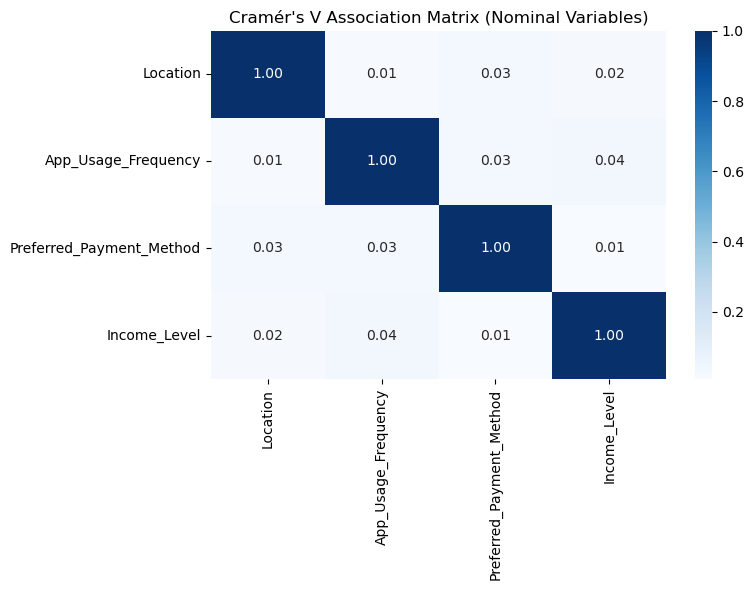

In [225]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    cramers_v_matrix,
    cmap="Blues",
    annot=True,
    fmt=".2f"
)
plt.title("Cramér's V Association Matrix (Nominal Variables)")
plt.tight_layout()
plt.show()


In [226]:
TARGET = "LTV"
TIME_COL = "Active_Days"

# sort by pseudo-time
df = df.sort_values(TIME_COL).reset_index(drop=True)


RANDOM_STATE = 42
n = len(df)
i1 = int(0.60 * n)
i2 = int(0.80 * n)

train_df = df.iloc[:i1].copy()
val_df   = df.iloc[i1:i2].copy()
test_df  = df.iloc[i2:].copy()

feature_cols = [c for c in df.columns if c != TARGET]

X_train, y_train = train_df[feature_cols], train_df[TARGET]
X_val,   y_val   = val_df[feature_cols],   val_df[TARGET]
X_test,  y_test  = test_df[feature_cols],  test_df[TARGET]

print("Shapes:", X_train.shape, X_val.shape, X_test.shape)
print("Active_Days medians:",
      train_df[TIME_COL].median(),
      val_df[TIME_COL].median(),
      test_df[TIME_COL].median())


Shapes: (4200, 14) (1400, 14) (1400, 14)
Active_Days medians: 108.0 254.0 326.0


In [227]:
cat_cols = ['Location', 'App_Usage_Frequency', 'Preferred_Payment_Method', 'Income_Level']

# Numeric columns except for target variable and categorical columns
num_cols = [c for c in feature_cols if c not in cat_cols]

# create preprocessors for future data processing
num_preprocess = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_preprocess = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", drop="first"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", num_preprocess, num_cols),
        ("cat", cat_preprocess, cat_cols)
    ],
    remainder="drop"
)


# convert to DataFrame to check the structures
X_train_df = pd.DataFrame(X_train, columns=feature_names, index=X_train.index)
X_val_df   = pd.DataFrame(X_val, columns=feature_names, index=X_val.index)
X_test_df  = pd.DataFrame(X_test, columns=feature_names, index=X_test.index)

print("Encoded shapes:", X_train_df.shape, X_val_enc_df.shape, X_test_df.shape)
print("Example encoded columns:", X_train_df.columns[:15].tolist())

Encoded shapes: (4200, 19) (1400, 19) (1400, 19)
Example encoded columns: ['num__Age', 'num__Total_Transactions', 'num__Active_Days', 'num__Last_Transaction_Days_Ago', 'num__Loyalty_Points_Earned', 'num__Referral_Count', 'num__Cashback_Received', 'num__Support_Tickets_Raised', 'num__Issue_Resolution_Time', 'num__Customer_Satisfaction_Score', 'cat__Location_Suburban', 'cat__Location_Urban', 'cat__App_Usage_Frequency_Monthly', 'cat__App_Usage_Frequency_Weekly', 'cat__Preferred_Payment_Method_Debit Card']


As we are going to use Random Forest, XGBoost, Gradient Boosting and MLP(Neural Net) models to test on the dataset to find the optimal model. We will need to scale the numerical data for MLP, but for the other models, scaling is not required. 

In [ ]:
# define the evaluation criteria
def eval_reg(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    return {"MAE": mae, "RMSE": rmse, "R2": r2}

# time-respecting CV on training split
tscv = TimeSeriesSplit(n_splits=5)

# Random Forest

In [228]:
# create pipeline for rf
rf_pipe = Pipeline([
    ("preprocess", preprocess),
    ("rf", RandomForestRegressor(random_state=42, n_jobs=-1, bootstrap=True))
])

# parameter set up
param_dist = {
    "rf__n_estimators": [100, 200, 300, 400, 500, 600, 700, 800, 900, 1000, 1250, 1500],
    "rf__max_depth": [None, 3, 5, 10, 15, 20, 25, 30, 35, 40],
    "rf__min_samples_split": [2, 5, 10, 20],
    "rf__min_samples_leaf": [1, 2, 4, 8],
    "rf__max_features": ["sqrt", 0.3, 0.5, 0.8],
}

rf_search = RandomizedSearchCV(
    estimator=rf_pipe,
    param_distributions=param_dist,
    n_iter=80, 
    scoring="neg_root_mean_squared_error",
    cv=tscv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)

# Fit on TRAIN only
rf_search.fit(X_train, y_train)

print("Best RF params:", rf_search.best_params_)
print("Best CV RMSE:", -rf_search.best_score_)


Fitting 5 folds for each of 80 candidates, totalling 400 fits
Best RF params: {'rf__n_estimators': 1250, 'rf__min_samples_split': 5, 'rf__min_samples_leaf': 2, 'rf__max_features': 0.8, 'rf__max_depth': 3}
Best CV RMSE: 339787.7077017369


In [229]:
# apply the best fit on the whole validation
best_rf = rf_search.best_estimator_

val_pred = best_rf.predict(X_val)
val_metrics = eval_reg(y_val, val_pred)

print("Validation metrics (tuned RF):", val_metrics)

Validation metrics (tuned RF): {'MAE': 259534.26014223916, 'RMSE': 334433.00172912184, 'R2': 0.4190490367712909}


In [230]:
# apply the best fit on the whole training + validation

X_trainval = pd.concat([X_train, X_val], axis=0)
y_trainval = pd.concat([y_train, y_val], axis=0)

best_rf.fit(X_trainval, y_trainval)

test_pred = best_rf.predict(X_test)
test_metrics = eval_reg(y_test, test_pred)

print("Test metrics (final tuned RF):", test_metrics)

Test metrics (final tuned RF): {'MAE': 246082.17365086742, 'RMSE': 325079.74060092564, 'R2': 0.4093534648445054}


In [233]:
# get the tuned RF model inside the best pipeline
best_rf_pipe = rf_search.best_estimator_
best_rf_model = best_rf_pipe.named_steps["rf"]

# clone params into a new RF with OOB enabled (same hyperparameters)
oob_rf = clone(best_rf_model)

oob_rf.set_params(
    bootstrap=True,
    oob_score=True,
    random_state=42,
    n_jobs=-1
)

X_train_oob = best_rf_pipe.named_steps["preprocess"].transform(X_train)
oob_rf.fit(X_train_oob, y_train)

print("OOB R² on training:", oob_rf.oob_score_)


OOB R² on training: 0.41418424107102003


# XGBoost

In [234]:
# create pipeline for xgboost
xgb_pipe = Pipeline([
    ("preprocess", preprocess),
    ("xgb", XGBRegressor(
        objective="reg:squarederror",
        tree_method="hist",
        random_state=42,
        n_jobs=-1
    ))
])


param_dist = {
    "xgb__n_estimators": [100, 200, 300, 400, 500, 600, 700, 800, 900, 1000, 1250, 1500],
    "xgb__max_depth": [3, 4, 5, 6, 7, 8],
    "xgb__learning_rate": [0.01, 0.03, 0.05, 0.08, 0.1, 0.15],
    "xgb__subsample": [0.6, 0.7, 0.8, 0.9, 1.0],
    "xgb__colsample_bytree": [0.6, 0.7, 0.8, 0.9, 1.0],
    "xgb__min_child_weight": [1, 5, 10, 15, 20],
    "xgb__reg_alpha": [0, 0.01, 0.05, 0.1, 0.3, 0.5, 0.7, 0.9, 1.0],
    "xgb__reg_lambda": [1.0, 3.0, 5.0, 7.0, 10.0],
}

xgb_search = RandomizedSearchCV(
    estimator=xgb_pipe,
    param_distributions=param_dist,
    n_iter=80,
    scoring="neg_root_mean_squared_error",
    cv=tscv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

xgb_search.fit(X_train, y_train)


print("Best XGB params:", xgb_search.best_params_)
print("Best CV RMSE:", -xgb_search.best_score_)


Fitting 5 folds for each of 80 candidates, totalling 400 fits


Best XGB params: {'xgb__subsample': 0.9, 'xgb__reg_lambda': 7.0, 'xgb__reg_alpha': 0.5, 'xgb__n_estimators': 100, 'xgb__min_child_weight': 1, 'xgb__max_depth': 3, 'xgb__learning_rate': 0.05, 'xgb__colsample_bytree': 0.7}
Best CV RMSE: 342051.94841538445


In [235]:
best_xgb = xgb_search.best_estimator_

val_pred = best_xgb.predict(X_val)
val_metrics = eval_reg(y_val, val_pred)

print("Validation metrics (XGB tuned):", val_metrics)

Validation metrics (XGB tuned): {'MAE': 258195.69746078664, 'RMSE': 336284.4420293394, 'R2': 0.4125988760462779}


In [236]:
X_trainval = pd.concat([X_train, X_val], axis=0)
y_trainval = pd.concat([y_train, y_val], axis=0)

best_xgb.fit(X_trainval, y_trainval)

test_pred = best_xgb.predict(X_test)
print(eval_reg(y_test, test_pred))

{'MAE': 242953.28556642827, 'RMSE': 324799.306177735, 'R2': 0.4103720836936904}


In [237]:
test_pred = best_xgb.predict(X_test)
test_metrics = eval_reg(y_test, test_pred)

print("Best XGBoost test metrics:", test_metrics)

Best XGBoost test metrics: {'MAE': 242953.28556642827, 'RMSE': 324799.306177735, 'R2': 0.4103720836936904}


# AdaBoost

In [ ]:
# create pipeline for adaboost

ada_pipe = Pipeline([
    ("preprocess", preprocess),
    ("adaboost", AdaBoostRegressor(
        estimator=DecisionTreeRegressor(random_state=42),
        random_state=42
    ))
])

In [239]:
n_estimators_range = range(1, 500, 10)

param_grid = {
    'adaboost__n_estimators': list(range(1, 500, 10)),
    'adaboost__learning_rate': [0.0001,0.001, 0.01, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
    'adaboost__estimator__max_depth': [1, 2, 3],
    'adaboost__estimator__min_samples_leaf': [5, 10]
}

ada_search = GridSearchCV(
    estimator=ada_pipe,
    param_grid=param_grid,
    scoring="neg_root_mean_squared_error",
    cv=tscv,
    n_jobs=-1,
    verbose=1
)

ada_search.fit(X_train, y_train)

print("Best AdaBoost params:", ada_search.best_params_)
print("Best CV RMSE:", -ada_search.best_score_)

Fitting 5 folds for each of 4200 candidates, totalling 21000 fits
Best AdaBoost params: {'adaboost__estimator__max_depth': 3, 'adaboost__estimator__min_samples_leaf': 10, 'adaboost__learning_rate': 0.2, 'adaboost__n_estimators': 31}
Best CV RMSE: 338329.5666064591


In [240]:
best_ada = ada_search.best_estimator_

val_pred = best_ada.predict(X_val)
val_metrics = eval_reg(y_val, val_pred)

print("Validation metrics (AdaBoost):", val_metrics)

Validation metrics (AdaBoost): {'MAE': 257388.43534946, 'RMSE': 334049.1830852725, 'R2': 0.4203817512827409}


In [241]:
X_trainval = pd.concat([X_train, X_val], axis=0)
y_trainval = pd.concat([y_train, y_val], axis=0)

best_ada.fit(X_trainval, y_trainval)

test_pred = best_ada.predict(X_test)
test_metrics = eval_reg(y_test, test_pred)

print("Final AdaBoost test metrics:", test_metrics)

Final AdaBoost test metrics: {'MAE': 243703.0336151705, 'RMSE': 325302.65214054956, 'R2': 0.4085431586134435}


# Neural Network - MLP

In [242]:
# initial testing on the 
mlp_base = MLPRegressor(
    hidden_layer_sizes=(128, 64),
    activation="relu",
    solver="adam",
    alpha=1e-3,               # L2 regularization
    learning_rate_init=1e-3,
    early_stopping=True,      # uses internal split from train only
    n_iter_no_change=20,
    max_iter=500,
    random_state=42
)

mlp_base.fit(X_train_scaled, y_train)

val_pred = mlp_base.predict(X_val_scaled)
print("Validation metrics (MLP baseline):", eval_reg(y_val, val_pred))

Validation metrics (MLP baseline): {'MAE': 269929.2063631313, 'RMSE': 340104.639060655, 'R2': 0.39917729824409476}


In [243]:
# create pipeline for MLP
mlp_pipe = Pipeline([
    ("preprocess", preprocess),
    ("mlp", MLPRegressor(
        solver="adam",
        early_stopping=True,
        n_iter_no_change=20,
        max_iter=1000,
        random_state=42
    ))
])


param_dist = {
    "mlp__hidden_layer_sizes": [(32,), (64,), (128,), (128, 64), (256, 128), (256, 128, 64)],
    "mlp__activation": ["relu", "tanh"],
    "mlp__alpha": [1e-5, 1e-4, 1e-3, 1e-2, 5e-2],
    "mlp__learning_rate_init": [1e-4, 3e-4, 1e-3, 3e-3, 5e-3, 1e-2],
    "mlp__batch_size": [32, 64, 128, 256],
}

mlp_search = RandomizedSearchCV(
    estimator=mlp_pipe,
    param_distributions=param_dist,
    n_iter=40,
    scoring="neg_root_mean_squared_error",
    cv=tscv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

mlp_search.fit(X_train, y_train)
best_mlp = mlp_search.best_estimator_

val_pred = best_mlp.predict(X_val)
print("MLP Val:", eval_reg(y_val, val_pred))

Fitting 5 folds for each of 40 candidates, totalling 200 fits
MLP Val: {'MAE': 257741.6407440092, 'RMSE': 335419.3749309881, 'R2': 0.41561708173283574}


In [244]:
best_mlp = mlp_search.best_estimator_

val_pred = best_mlp.predict(X_val)
print("Validation metrics (MLP tuned):", eval_reg(y_val, val_pred))

Validation metrics (MLP tuned): {'MAE': 257741.6407440092, 'RMSE': 335419.3749309881, 'R2': 0.41561708173283574}


In [245]:
# Combine train+val
X_trainval = pd.concat([X_train, X_val], axis=0)
y_trainval = pd.concat([y_train, y_val], axis=0)

# Refit best MLP on train+val
best_mlp = mlp_search.best_estimator_
best_mlp.fit(X_trainval, y_trainval)

# Test once
test_pred = best_mlp.predict(X_test)
print("Final MLP test metrics:", eval_reg(y_test, test_pred))

Final MLP test metrics: {'MAE': 242519.64516447805, 'RMSE': 324373.99952721735, 'R2': 0.4119152427025029}


Log transformation

In [249]:
y_train_log = np.log1p(y_train)

# create pipeline for MLP log transformation
mlp_pipe = Pipeline([
    ("preprocess", preprocess), 
    ("mlp", MLPRegressor(
        solver="adam",
        early_stopping=True,
        n_iter_no_change=20,
        max_iter=1000,
        random_state=42
    ))
])

log_mlp = TransformedTargetRegressor(
    regressor=mlp_pipe,
    func=np.log1p,
    inverse_func=np.expm1
)

param_dist = {
    "mlp__hidden_layer_sizes": [(32,), (64,), (128,), (128,64), (256,128), (256,128,64)],
    "mlp__activation": ["relu", "tanh"],
    "mlp__alpha": [1e-5, 1e-4, 1e-3, 1e-2, 5e-2],
    "mlp__learning_rate_init": [1e-4, 3e-4, 1e-3, 3e-3, 5e-3, 1e-2],
    "mlp__batch_size": [32, 64, 128, 256],
}

mlp_log_search = RandomizedSearchCV(
    estimator=mlp_pipe,
    param_distributions=param_dist,
    n_iter=40,
    scoring="neg_root_mean_squared_error",
    cv=tscv,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

mlp_log_search.fit(X_train, y_train_log)


Fitting 5 folds for each of 40 candidates, totalling 200 fits


,estimator,Pipeline(step...m_state=42))])
,param_distributions,"{'mlp__activation': ['relu', 'tanh'], 'mlp__alpha': [1e-05, 0.0001, ...], 'mlp__batch_size': [32, 64, ...], 'mlp__hidden_layer_sizes': [(32,), (64,), ...], ...}"
,n_iter,40
,scoring,'neg_root_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,TimeSeriesSpl...est_size=None)
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [250]:
best_log_mlp = mlp_log_search.best_estimator_

val_pred = best_log_mlp.predict(X_val)
print("MLP (log target) Val:", eval_reg(y_val, val_pred))

MLP (log target) Val: {'MAE': 528046.1943555181, 'RMSE': 686552.001635944, 'R2': -1.448319534055205}


In [251]:
X_trainval = pd.concat([X_train, X_val], axis=0)
y_trainval = pd.concat([y_train, y_val], axis=0)

final_log_mlp = mlp_log_search.best_estimator_
final_log_mlp.fit(X_trainval, y_trainval)

test_pred = final_log_mlp.predict(X_test)
print("MLP (log target) Test:", eval_reg(y_test, test_pred))

MLP (log target) Test: {'MAE': 483887.2976507485, 'RMSE': 642700.6595836622, 'R2': -1.3086885168247777}


Combine

In [252]:
def evaluate_model(name, model, X_val, y_val, X_test, y_test):
    val_pred = model.predict(X_val)
    test_pred = model.predict(X_test)

    val_m = eval_reg(y_val, val_pred)
    test_m = eval_reg(y_test, test_pred)

    row = {
        "Model": name,
        "Val_MAE": val_m["MAE"],
        "Val_RMSE": val_m["RMSE"],
        "Val_R2": val_m["R2"],
        "Test_MAE": test_m["MAE"],
        "Test_RMSE": test_m["RMSE"],
        "Test_R2": test_m["R2"],
    }
    return row


In [253]:
rows = []
rows.append(evaluate_model("Random Forest", best_rf,  X_val,        y_val, X_test,        y_test))
rows.append(evaluate_model("XGBoost",       best_xgb, X_val,        y_val, X_test,        y_test))
rows.append(evaluate_model("AdaBoost",      best_ada, X_val,        y_val, X_test,        y_test))
rows.append(evaluate_model("MLP",           best_mlp, X_val,        y_val, X_test,        y_test))
rows.append(evaluate_model("MLP Log",       best_log_mlp, X_val,    y_val, X_test,        y_test))


results_df = pd.DataFrame(rows).sort_values("Val_RMSE").reset_index(drop=True)
results_df

# LTV mean value: 5.119197e+05

,Model,Val_MAE,Val_RMSE,Val_R2,Test_MAE,Test_RMSE,Test_R2
0,XGBoost,249268.945307,323845.514927,0.455250,242953.285566,324799.306178,0.410372
1,Random Forest,256901.261903,331306.521415,0.429860,246082.173651,325079.740601,0.409353
2,AdaBoost,255966.348018,331763.074230,0.428288,243703.033615,325302.652141,0.408543
3,MLP,255278.298014,332831.307579,0.424600,242519.645164,324373.999527,0.411915
4,MLP Log,528025.790038,686536.619770,-1.448210,483887.297651,642700.659584,-1.308689


Based on the result of validation set details, XGBoost has the best/lowest RMSE value, which is 323845.514927 with R2 0.455250. The RMSE on test dataset is 324799.306178 with R2 0.410372. The performance between training, validation and testing are consistent. 

Our LTV mean value is 5.119197e+05. The validation and test RMSE result is around 60% of the LTV mean. 